# EDA: Предсказание выкупа заказа

**Цель:** Проанализировать данные о заказах медицинских товаров для построения модели предсказания вероятности выкупа заказа.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

DATA_PATH = Path("../data/raw/MIPT_hackathon_dataset.csv")

## 1. Загрузка и обзор данных

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

Размер датасета: 5383 строк, 96 колонок


,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_Дата перехода Передан в доставку,lead_Ответственный за доставку,lead_Нумерация сделки,lead_Дата приобретения изделия,lead_Поиск товаров GoSklad,lead_ACTUAL-FORMAT,lead_BANNER-SIZES,lead_WIDTH,lead_HEIGHT,lead_Список товаров GoSklad
0,LEAD_0217,1761974724,2025-11-01,True,False,1.762243e+09,1.762505e+09,1.762602e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LEAD_0220,1761975068,2025-11-01,True,False,1.762243e+09,1.762690e+09,1.762789e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LEAD_0058,1761976628,2025-11-01,True,False,1.762252e+09,1.762682e+09,1.762749e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0221,1761976896,2025-11-01,False,False,1.762243e+09,1.762527e+09,NaN,1.764142e+09,1.764676e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LEAD_0218,1761977233,2025-11-01,True,False,1.762245e+09,1.762574e+09,1.762583e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Типы данных:")
print(df.dtypes.value_counts())

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame(
    {"missing_count": missing, "missing_percent": missing_pct}
).sort_values("missing_percent", ascending=False)

print("\nКолонки с пропусками (>0%):")
print(missing_df[missing_df["missing_count"] > 0].head(20))

Типы данных:
str        44
float64    38
int64      10
bool        3
object      1
Name: count, dtype: int64

Колонки с пропусками (>0%):
                                missing_count  missing_percent
lead_loss_reason_id                      5383            100.0
lead_Дата приобретения изделия           5381            100.0
lead_Поиск товаров GoSklad               5382            100.0
lead_ACTUAL-FORMAT                       5382            100.0
lead_BANNER-SIZES                        5382            100.0
lead_WIDTH                               5382            100.0
lead_HEIGHT                              5382            100.0
lead_Нумерация сделки                    5382            100.0
lead_Счет оплачен                        5381            100.0
lead_Список товаров GoSklad              5382            100.0
lead_ПВЗ СДЭК                            5372             99.8
lead_Оплачено клиентом                   5371             99.8
lead_Тип отправления                     53

## 2. Анализ целевой переменной

Распределение целевой переменной 'buyout_flag':
buyout_flag
True     4278
False    1016
Name: count, dtype: int64

Доля выкупа: 80.81%


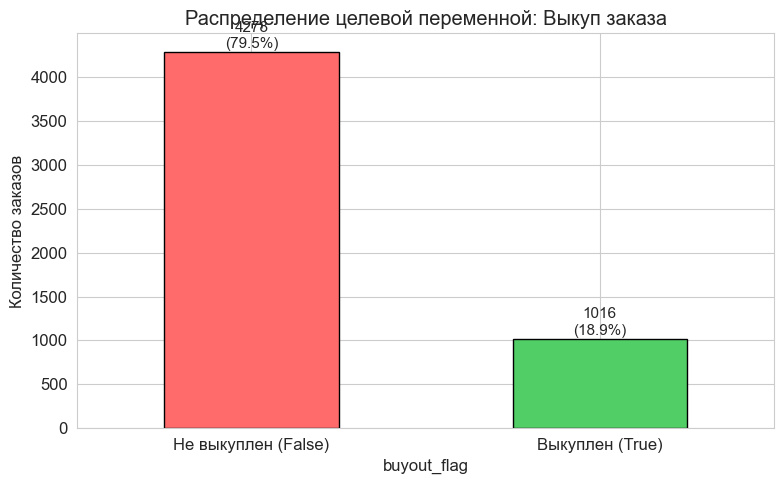

In [4]:
print("Распределение целевой переменной 'buyout_flag':")
print(df["buyout_flag"].value_counts())
print(f"\nДоля выкупа: {df['buyout_flag'].mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#ff6b6b", "#51cf66"]
df["buyout_flag"].value_counts().plot(
    kind="bar", color=colors, ax=ax, edgecolor="black"
)
ax.set_title("Распределение целевой переменной: Выкуп заказа")
ax.set_xlabel("buyout_flag")
ax.set_ylabel("Количество заказов")
ax.set_xticklabels(["Не выкуплен (False)", "Выкуплен (True)"], rotation=0)
for i, v in enumerate(df["buyout_flag"].value_counts()):
    ax.text(i, v + 50, f"{v}\n({v / len(df) * 100:.1f}%)", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Анализ признаков по группам

### 3.1 Временные признаки

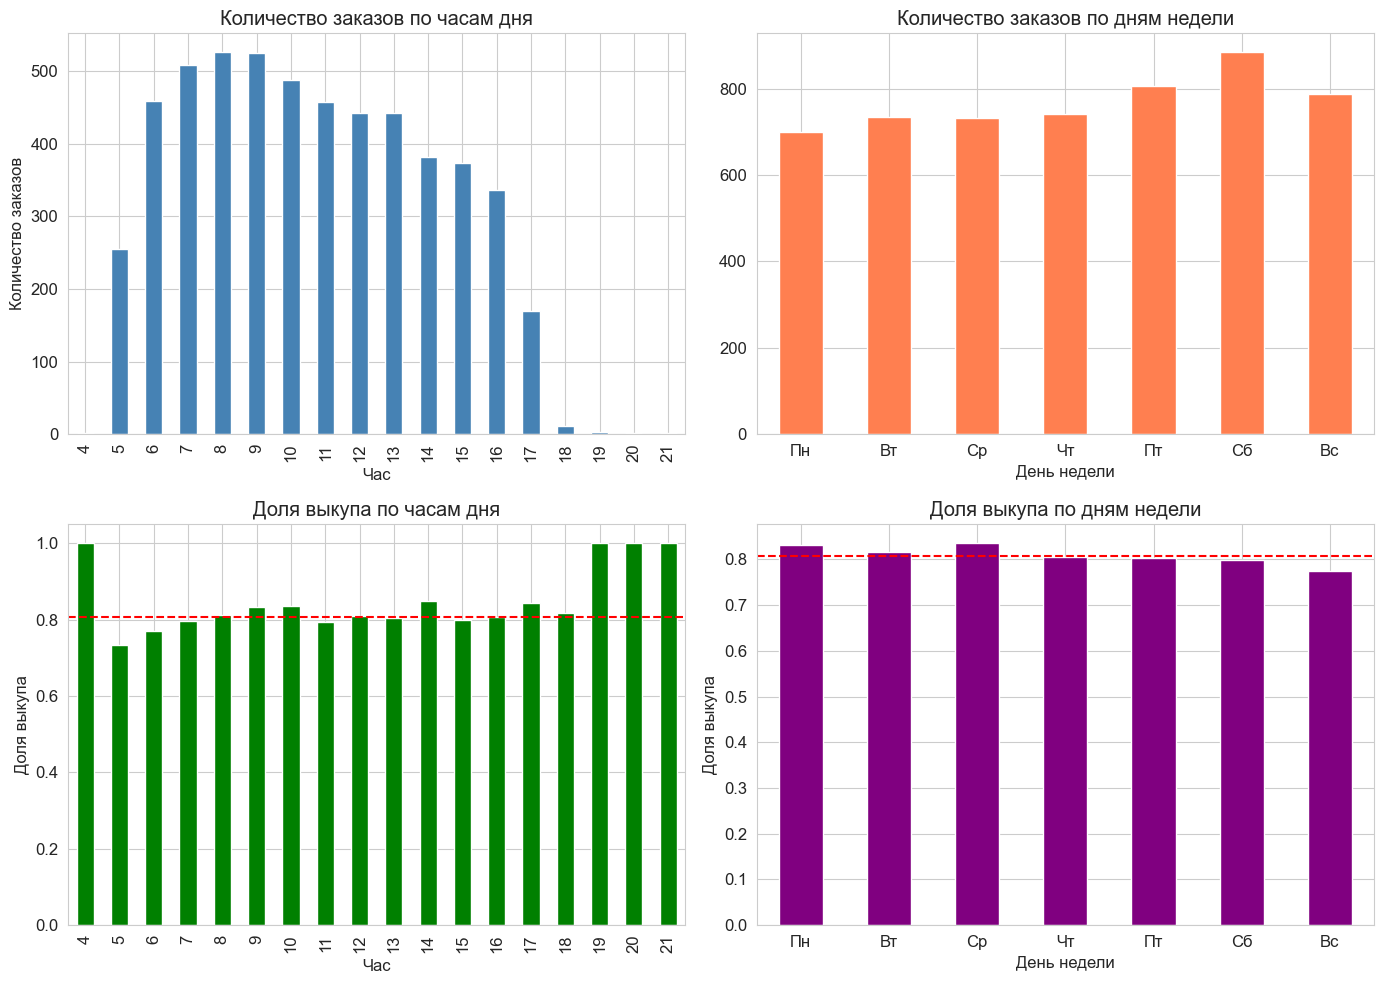

In [5]:
df["sale_datetime"] = pd.to_datetime(df["sale_ts"], unit="s")
df["created_datetime"] = pd.to_datetime(df["lead_created_at"], unit="s")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby(df["sale_datetime"].dt.hour).size().plot(
    kind="bar", ax=axes[0, 0], color="steelblue"
)
axes[0, 0].set_title("Количество заказов по часам дня")
axes[0, 0].set_xlabel("Час")
axes[0, 0].set_ylabel("Количество заказов")

days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
df.groupby(df["sale_datetime"].dt.dayofweek).size().plot(
    kind="bar", ax=axes[0, 1], color="coral"
)
axes[0, 1].set_title("Количество заказов по дням недели")
axes[0, 1].set_xlabel("День недели")
axes[0, 1].set_xticklabels(days, rotation=0)

hourly_buyout = df.groupby(df["sale_datetime"].dt.hour)["buyout_flag"].mean()
hourly_buyout.plot(kind="bar", ax=axes[1, 0], color="green")
axes[1, 0].set_title("Доля выкупа по часам дня")
axes[1, 0].set_xlabel("Час")
axes[1, 0].set_ylabel("Доля выкупа")
axes[1, 0].axhline(
    y=df["buyout_flag"].mean(), color="red", linestyle="--", label="Среднее"
)

daily_buyout = df.groupby(df["sale_datetime"].dt.dayofweek)["buyout_flag"].mean()
daily_buyout.plot(kind="bar", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Доля выкупа по дням недели")
axes[1, 1].set_xlabel("День недели")
axes[1, 1].set_xticklabels(days, rotation=0)
axes[1, 1].set_ylabel("Доля выкупа")
axes[1, 1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

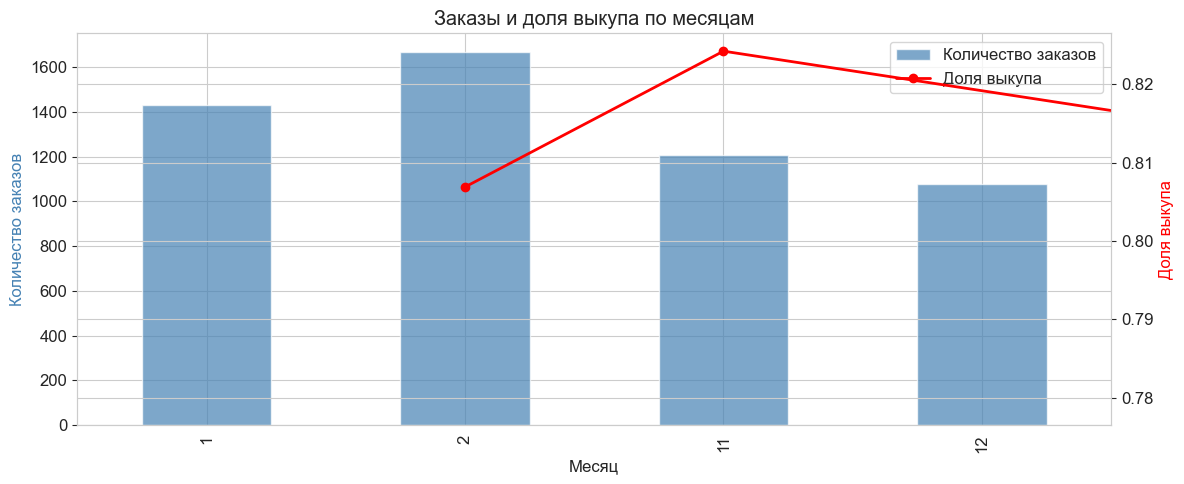

In [6]:
df["sale_month"] = df["sale_datetime"].dt.month

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
df.groupby("sale_month").size().plot(
    kind="bar", ax=ax, color="steelblue", alpha=0.7, label="Количество заказов"
)
df.groupby("sale_month")["buyout_flag"].mean().plot(
    kind="line", ax=ax2, color="red", marker="o", linewidth=2, label="Доля выкупа"
)

ax.set_title("Заказы и доля выкупа по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Количество заказов", color="steelblue")
ax2.set_ylabel("Доля выкупа", color="red")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

### 3.2 Финансовые признаки

In [7]:
financial_cols = [
    "lead_price",
    "lead_Скидка",
    "lead_Сумма заказа",
    "lead_Стоимость доставки",
    "lead_Сумма наложенного платежа (руб)",
]

print("Статистика финансовых признаков:")
df[financial_cols].describe().round(2)

Статистика финансовых признаков:


,lead_price,lead_Скидка,lead_Сумма заказа,lead_Сумма наложенного платежа (руб)
count,5383.00,1144.00,217.00,957.00
mean,13457.75,13.78,10316.80,13005.44
std,11176.97,6.65,9957.75,8300.78
min,0.00,0.00,1585.00,1416.00
25%,8080.00,10.00,5175.00,8230.00
50%,10795.00,10.00,8020.00,10580.00
75%,16570.00,15.00,11230.00,16170.00
max,413432.00,35.00,105805.00,119202.00


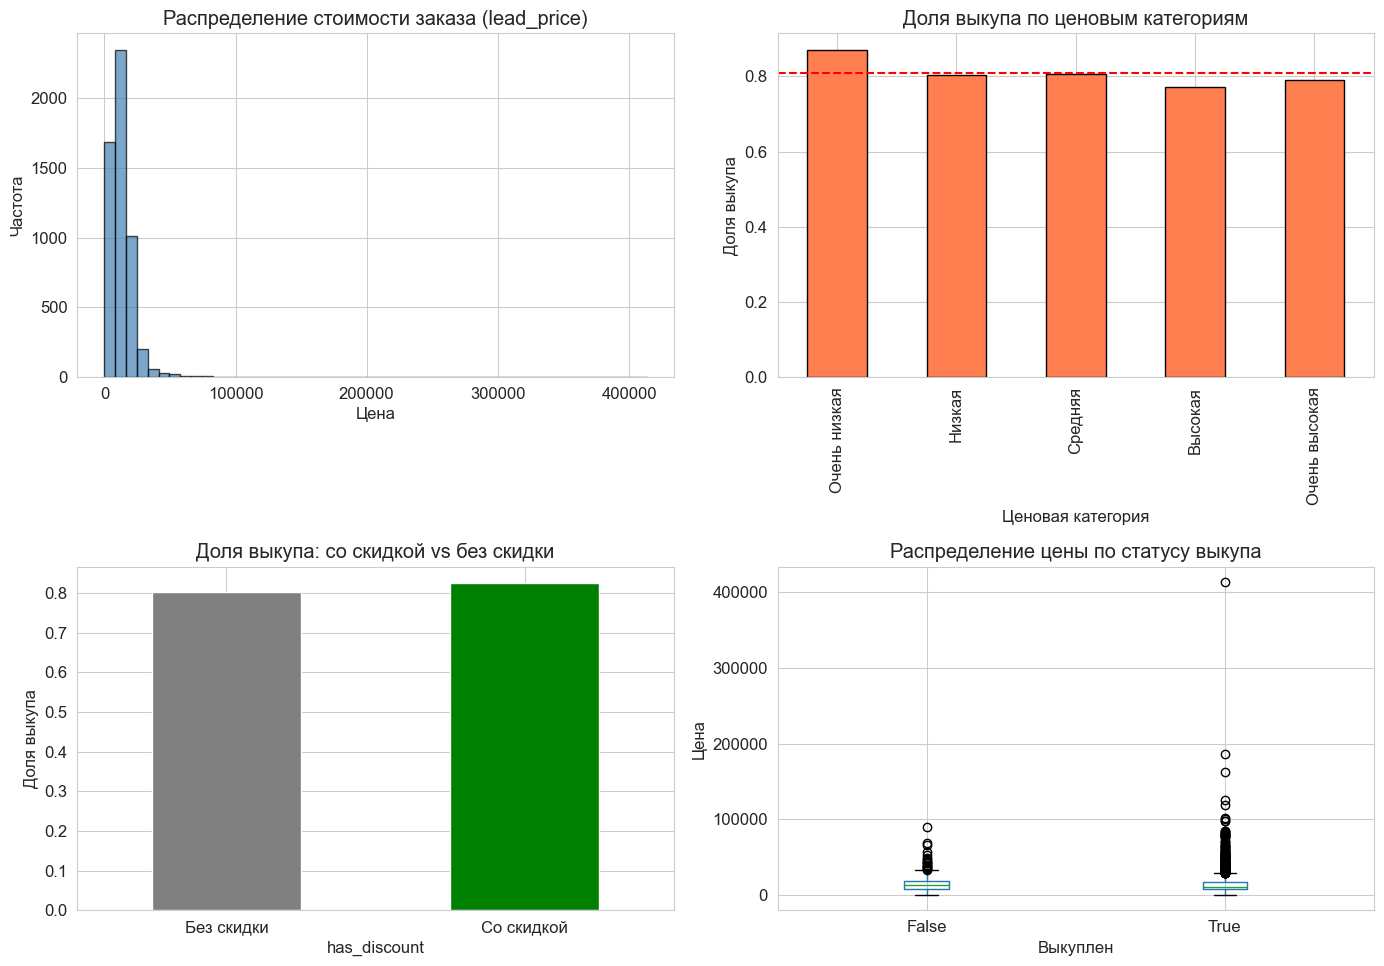

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(
    df["lead_price"].dropna(), bins=50, color="steelblue", edgecolor="black", alpha=0.7
)
axes[0, 0].set_title("Распределение стоимости заказа (lead_price)")
axes[0, 0].set_xlabel("Цена")
axes[0, 0].set_ylabel("Частота")

df["price_category"] = pd.qcut(
    df["lead_price"].dropna(),
    q=5,
    labels=["Очень низкая", "Низкая", "Средняя", "Высокая", "Очень высокая"],
)
df.groupby("price_category")["buyout_flag"].mean().plot(
    kind="bar", ax=axes[0, 1], color="coral", edgecolor="black"
)
axes[0, 1].set_title("Доля выкупа по ценовым категориям")
axes[0, 1].set_xlabel("Ценовая категория")
axes[0, 1].set_ylabel("Доля выкупа")
axes[0, 1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

df["has_discount"] = (df["lead_Скидка"] > 0).astype(int)
df.groupby("has_discount")["buyout_flag"].mean().plot(
    kind="bar", ax=axes[1, 0], color=["gray", "green"]
)
axes[1, 0].set_title("Доля выкупа: со скидкой vs без скидки")
axes[1, 0].set_xticklabels(["Без скидки", "Со скидкой"], rotation=0)
axes[1, 0].set_ylabel("Доля выкупа")

df.boxplot(column="lead_price", by="buyout_flag", ax=axes[1, 1])
axes[1, 1].set_title("Распределение цены по статусу выкупа")
axes[1, 1].set_xlabel("Выкуплен")
axes[1, 1].set_ylabel("Цена")
plt.suptitle("")

plt.tight_layout()
plt.show()

### 3.3 Логистические признаки

In [9]:
print("Служба доставки:")
print(df["lead_Служба доставки"].value_counts())

print("\nМетод доставки:")
print(df["lead_Метод доставки"].value_counts())

Служба доставки:
lead_Служба доставки
СДЭК до ПВЗ      3695
Почта             985
СДЭК до Двери     696
Самовывоз           2
Name: count, dtype: int64

Метод доставки:
lead_Метод доставки
В пункт выдачи товаров (СДЭК)    187
Курьером (СДЭК)                   30
Name: count, dtype: int64


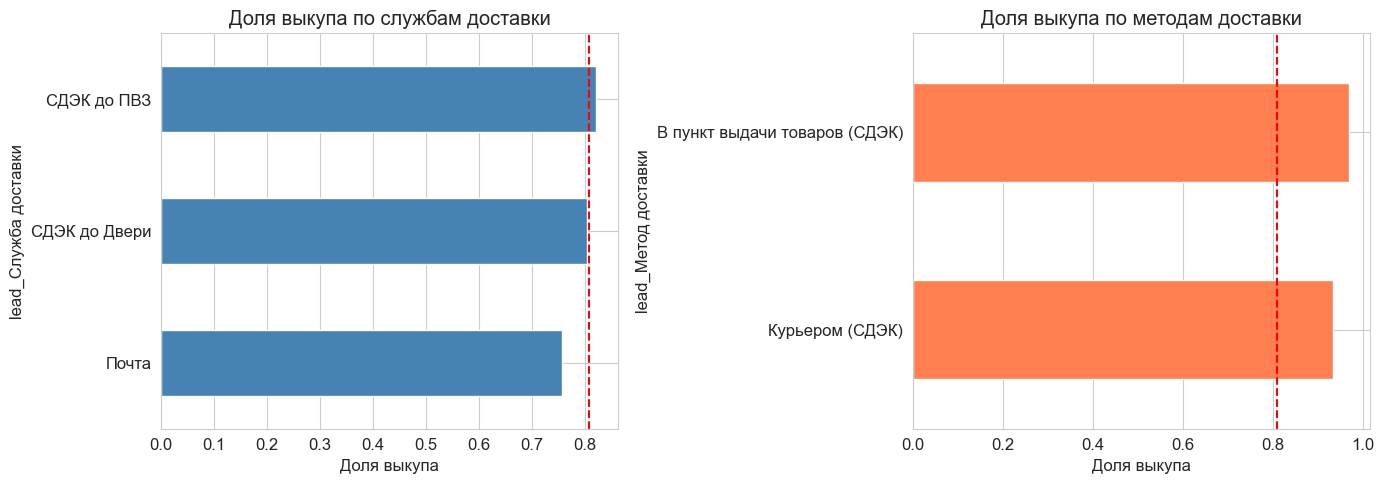

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivery_buyout = df.groupby("lead_Служба доставки")["buyout_flag"].agg(
    ["mean", "count"]
)
delivery_buyout = delivery_buyout[delivery_buyout["count"] >= 20].sort_values("mean")
delivery_buyout["mean"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Доля выкупа по службам доставки")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

method_buyout = df.groupby("lead_Метод доставки")["buyout_flag"].agg(["mean", "count"])
method_buyout = method_buyout[method_buyout["count"] >= 20].sort_values("mean")
method_buyout["mean"].plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Доля выкупа по методам доставки")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.4 Географические признаки

In [11]:
print("Топ-20 городов по количеству заказов:")
city_stats = (
    df.groupby("contact_Город")
    .agg({"lead_id": "count", "buyout_flag": "mean"})
    .rename(columns={"lead_id": "count", "buyout_flag": "buyout_rate"})
)
city_stats = city_stats.sort_values("count", ascending=False).head(20)
print(city_stats.round(3))

Топ-20 городов по количеству заказов:
                 count buyout_rate
contact_Город                     
Москва             582    0.839378
Санкт-Петербург    209    0.860577
Екатеринбург        82    0.804878
Новосибирск         72    0.901408
Челябинск           56    0.803571
Уфа                 52    0.711538
Краснодар           51    0.784314
Самара              50        0.86
Нижний Новгород     47     0.87234
Красноярск          44    0.674419
Омск                43    0.906977
Тюмень              42    0.785714
Хабаровск           40    0.692308
Казань              38    0.894737
Воронеж             38    0.756757
Пермь               37    0.783784
Ижевск              35    0.823529
Саратов             35    0.857143
Волгоград           34    0.794118
Рязань              33    0.939394


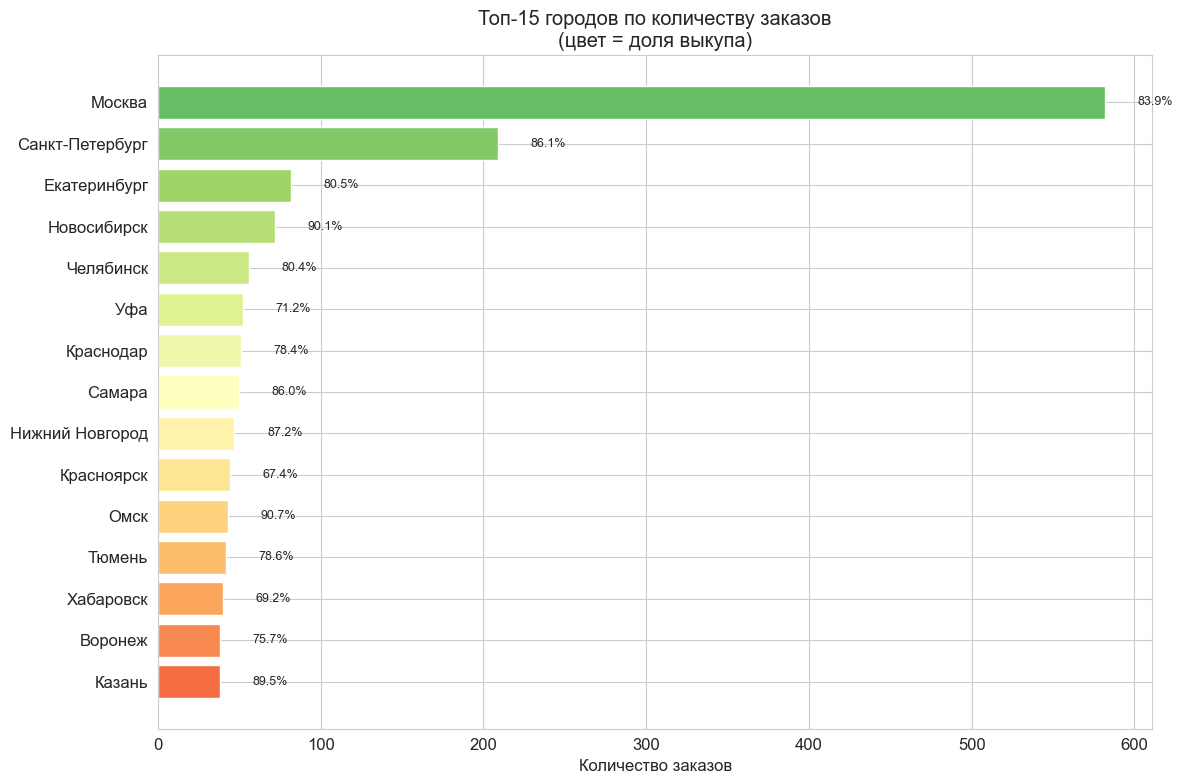

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

top_cities = city_stats.head(15).sort_values("count")
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_cities)))

bars = ax.barh(top_cities.index, top_cities["count"], color=colors)
ax.set_title("Топ-15 городов по количеству заказов\n(цвет = доля выкупа)")
ax.set_xlabel("Количество заказов")

for i, (city, row) in enumerate(top_cities.iterrows()):
    ax.text(row["count"] + 20, i, f"{row['buyout_rate']:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 3.5 Источники трафика (UTM)

In [13]:
print("UTM Source:")
print(df["lead_utm_source"].value_counts().head(10))

print("\nUTM Medium:")
print(df["lead_utm_medium"].value_counts().head(10))

UTM Source:
lead_utm_source
ppc_ru_yandex_art_npz          1109
ppc_ru_yandex_otek_dem          825
ppc_ru_yandex_sustav_dem        421
ppc_ru_yandex_sleep_dem         335
ppc_ru_yandex_varikoz_dem       280
ppc_ru_yandex_davlenie2_dem     175
Неизвестно                      174
ppc_ru_yandex_ssz_dem            64
ppc_ru_yandex_sustav2_dem        44
abdm                             32
Name: count, dtype: int64

UTM Medium:
lead_utm_medium
cpc           3336
Неизвестно     174
Bloger           5
Name: count, dtype: int64


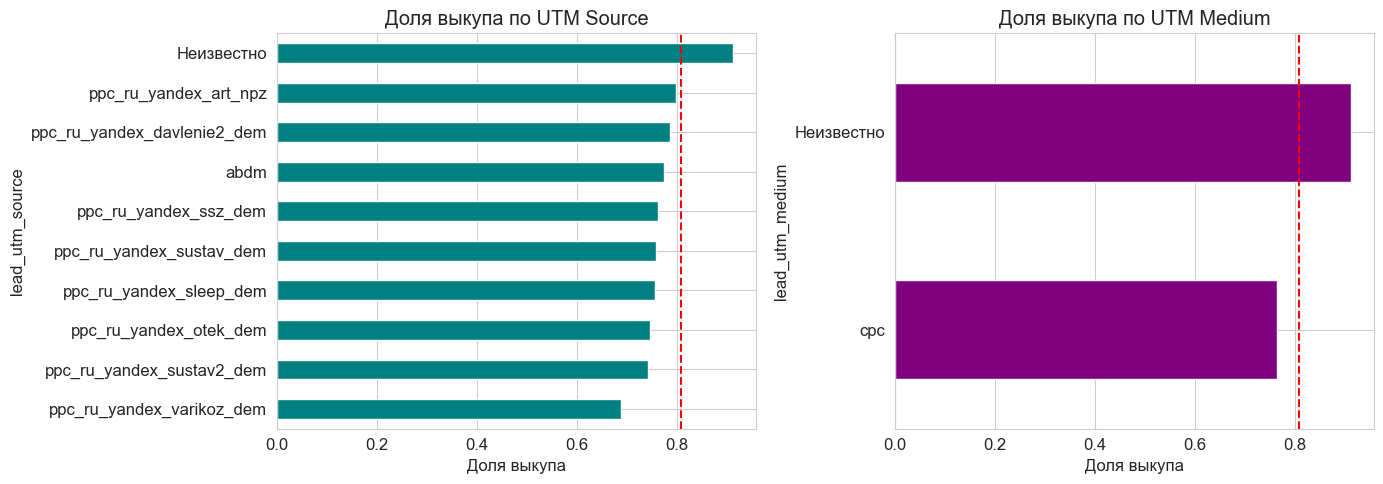

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

utm_source_stats = (
    df.groupby("lead_utm_source").agg({"buyout_flag": ["mean", "count"]}).round(3)
)
utm_source_stats.columns = ["buyout_rate", "count"]
utm_source_stats = utm_source_stats[utm_source_stats["count"] >= 30].sort_values(
    "buyout_rate"
)
utm_source_stats["buyout_rate"].plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Доля выкупа по UTM Source")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

utm_medium_stats = (
    df.groupby("lead_utm_medium").agg({"buyout_flag": ["mean", "count"]}).round(3)
)
utm_medium_stats.columns = ["buyout_rate", "count"]
utm_medium_stats = utm_medium_stats[utm_medium_stats["count"] >= 30].sort_values(
    "buyout_rate"
)
utm_medium_stats["buyout_rate"].plot(kind="barh", ax=axes[1], color="purple")
axes[1].set_title("Доля выкупа по UTM Medium")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.6 Квалификация лида

In [15]:
print("Квалификация лида:")
print(df["lead_Квалификация лида"].value_counts())

print("\nLead Quality:")
print(df["lead_LEADQUALIFYCATION"].value_counts())

Квалификация лида:
lead_Квалификация лида
А - лид       2961
В - лид       1469
С - лид        873
Неквал лид      59
D - лид          7
Name: count, dtype: int64

Lead Quality:
lead_LEADQUALIFYCATION
a    975
Name: count, dtype: int64


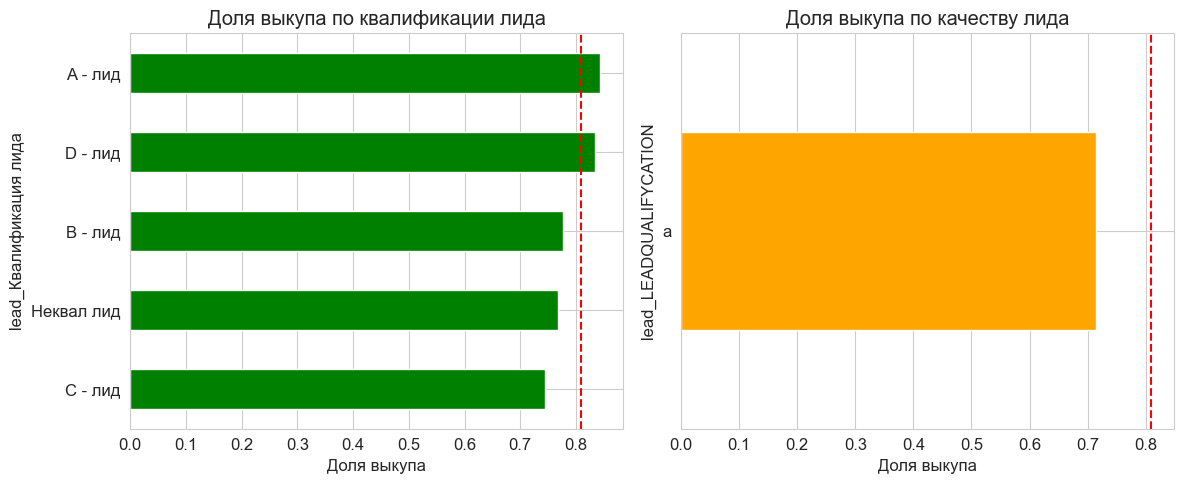

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

qual_stats = df.groupby("lead_Квалификация лида").agg(
    {"buyout_flag": ["mean", "count"]}
)
qual_stats.columns = ["buyout_rate", "count"]
qual_stats = qual_stats.sort_values("buyout_rate")
qual_stats["buyout_rate"].plot(kind="barh", ax=axes[0], color="green")
axes[0].set_title("Доля выкупа по квалификации лида")
axes[0].set_xlabel("Доля выкупа")
axes[0].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

lead_qual_stats = df.groupby("lead_LEADQUALIFYCATION").agg(
    {"buyout_flag": ["mean", "count"]}
)
lead_qual_stats.columns = ["buyout_rate", "count"]
lead_qual_stats = lead_qual_stats.sort_values("buyout_rate")
lead_qual_stats["buyout_rate"].plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Доля выкупа по качеству лида")
axes[1].set_xlabel("Доля выкупа")
axes[1].axvline(x=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

### 3.7 Продуктовые признаки

In [17]:
print("Категории товаров:")
print(df["lead_Категория и варианты выбора"].value_counts())

Категории товаров:
lead_Категория и варианты выбора
S                3226
I                1245
D                 683
C                 140
Нет категории      76
Name: count, dtype: int64


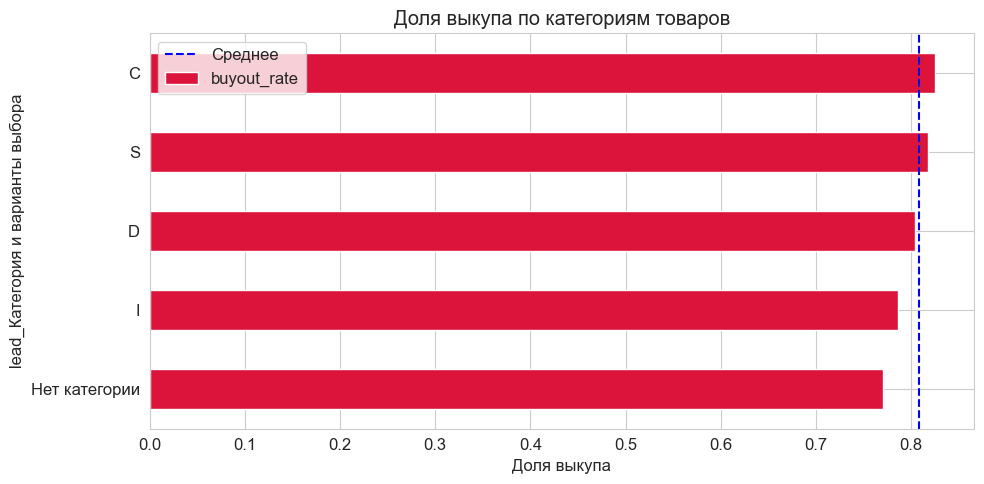

In [18]:
cat_stats = df.groupby("lead_Категория и варианты выбора").agg(
    {"buyout_flag": ["mean", "count"]}
)
cat_stats.columns = ["buyout_rate", "count"]
cat_stats = cat_stats.sort_values("buyout_rate")

fig, ax = plt.subplots(figsize=(10, 5))
cat_stats["buyout_rate"].plot(kind="barh", ax=ax, color="crimson")
ax.set_title("Доля выкупа по категориям товаров")
ax.set_xlabel("Доля выкупа")
ax.axvline(x=df["buyout_flag"].mean(), color="blue", linestyle="--", label="Среднее")
ax.legend()

plt.tight_layout()
plt.show()

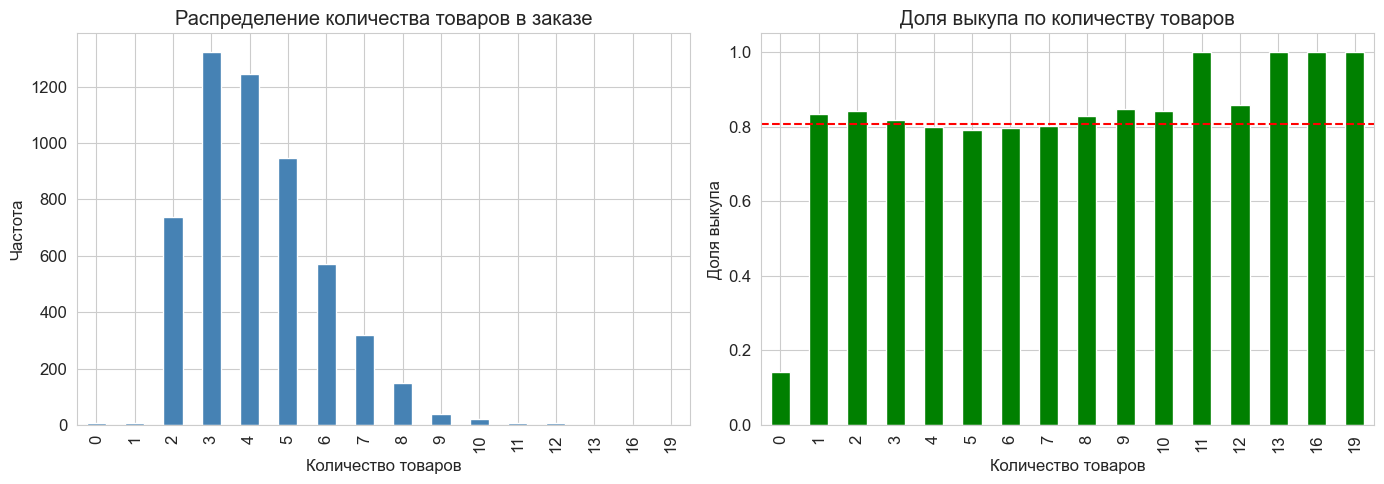

In [19]:
import re


def count_items(text):
    if pd.isna(text):
        return 0
    return len(re.findall(r"\d+\)\s+[А-Яа-яёЁA-Za-z]", str(text)))


df["n_items"] = df["lead_Состав заказа"].apply(count_items)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["n_items"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Распределение количества товаров в заказе")
axes[0].set_xlabel("Количество товаров")
axes[0].set_ylabel("Частота")

items_buyout = df.groupby("n_items")["buyout_flag"].agg(["mean", "count"])
items_buyout["mean"].plot(kind="bar", ax=axes[1], color="green")
axes[1].set_title("Доля выкупа по количеству товаров")
axes[1].set_xlabel("Количество товаров")
axes[1].set_ylabel("Доля выкупа")
axes[1].axhline(y=df["buyout_flag"].mean(), color="red", linestyle="--")

plt.tight_layout()
plt.show()

## 4. Корреляционный анализ

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_ts = [
    "sale_ts",
    "lead_created_at",
    "lead_updated_at",
    "contact_created_at",
    "contact_updated_at",
]
numeric_cols = [c for c in numeric_cols if c not in exclude_ts]

correlations = (
    df[numeric_cols + ["buyout_flag"]]
    .corr()["buyout_flag"]
    .drop("buyout_flag")
    .sort_values()
)

print("Признаки с наибольшей положительной корреляцией с выкупом:")
print(correlations.tail(10))

print("\nПризнаки с наибольшей отрицательной корреляцией с выкупом:")
print(correlations.head(10))

Признаки с наибольшей положительной корреляцией с выкупом:
lead_Скидка                         0.133336
lead_Дата приобретения изделия      1.000000
received_ts                              NaN
lead_loss_reason_id                      NaN
lead_Дата получения денег на Р/С         NaN
lead_Оплачено клиентом                   NaN
lead_Нумерация сделки                    NaN
lead_ACTUAL-FORMAT                       NaN
lead_WIDTH                               NaN
lead_HEIGHT                              NaN
Name: buyout_flag, dtype: float64

Признаки с наибольшей отрицательной корреляцией с выкупом:
days_to_outcome             -0.695943
lead_status_id              -0.443550
current_status_id           -0.443388
closed_ts                   -0.338917
lead_Сумма заказа           -0.119452
returned_ts                 -0.104238
lead_closed_at              -0.101812
days_handed_to_issued_pvz   -0.100902
lead_LTV                    -0.061806
lead_pipeline_id            -0.060564
Name: buyout_flag

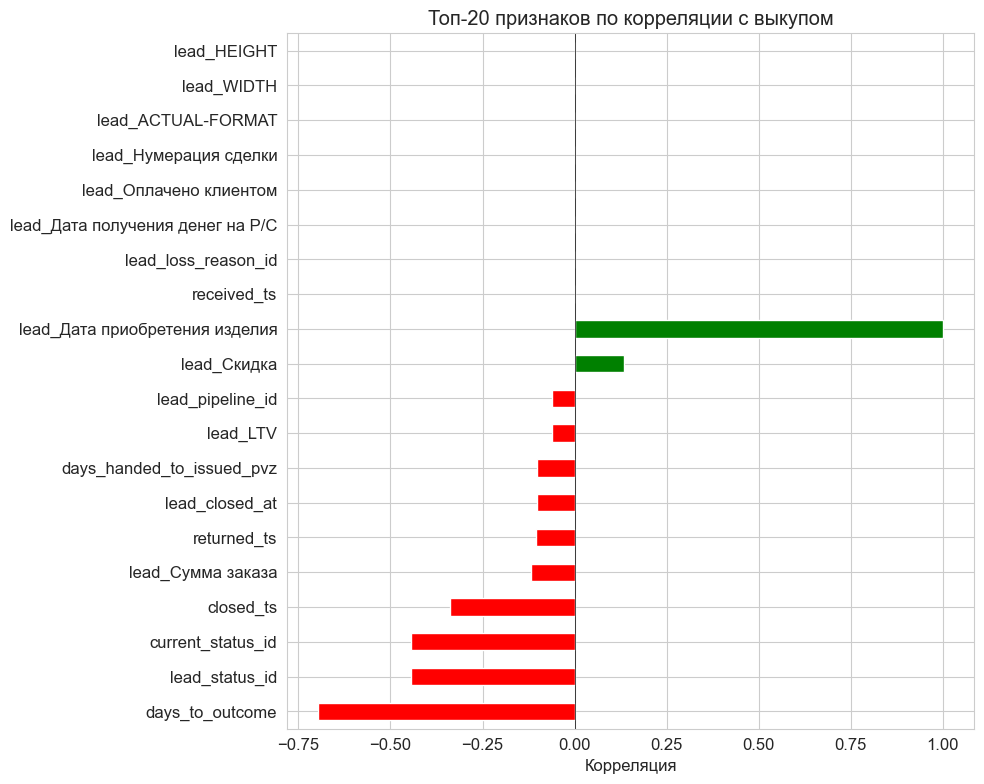

In [21]:
top_corr = pd.concat([correlations.head(10), correlations.tail(10)])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["red" if v < 0 else "green" for v in top_corr.values]
top_corr.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Топ-20 признаков по корреляции с выкупом")
ax.set_xlabel("Корреляция")
ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

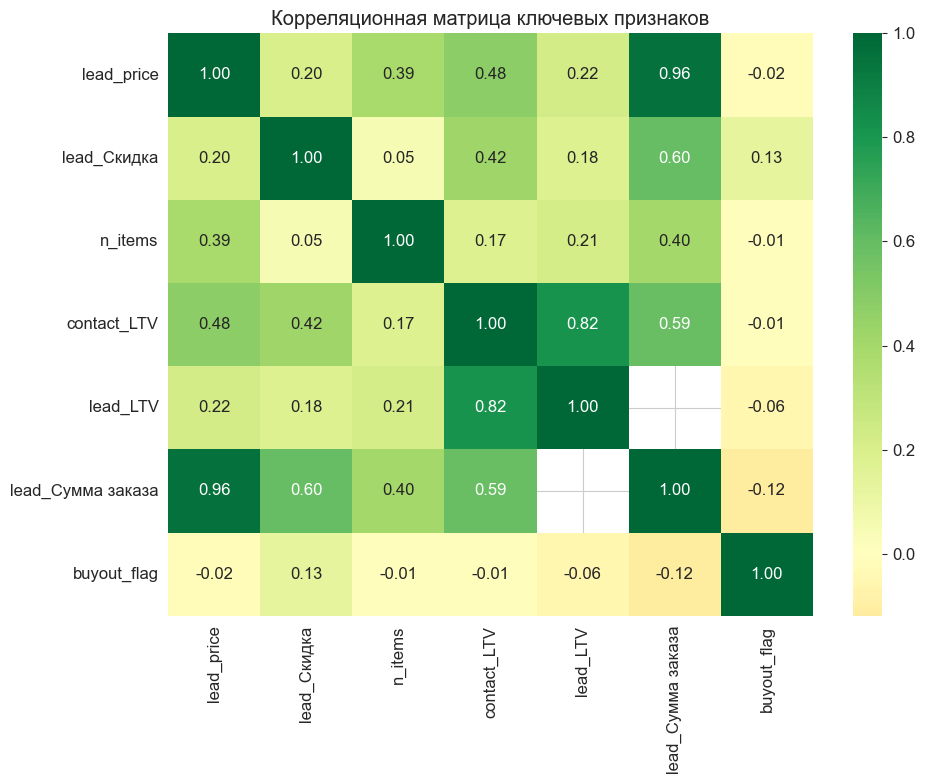

In [22]:
key_features = [
    "lead_price",
    "lead_Скидка",
    "n_items",
    "contact_LTV",
    "lead_LTV",
    "lead_Сумма заказа",
    "buyout_flag",
]
key_features = [f for f in key_features if f in df.columns]

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Корреляционная матрица ключевых признаков")

plt.tight_layout()
plt.show()

## 5. Выявление признаков-утечек

In [23]:
leakage_columns = [
    "handed_to_delivery_ts",
    "issued_or_pvz_ts",
    "received_ts",
    "rejected_ts",
    "returned_ts",
    "days_sale_to_handed",
    "days_handed_to_issued_pvz",
    "days_to_outcome",
    "lifecycle_incomplete",
    "current_status_id",
    "closed_ts",
    "lead_closed_at",
    "lead_loss_reason_id",
    "outcome_unknown",
]

print("⚠️ ПРИЗНАКИ-УТЕЧКИ (должны быть удалены перед обучением):")
for col in leakage_columns:
    if col in df.columns:
        print(f"  - {col}")

⚠️ ПРИЗНАКИ-УТЕЧКИ (должны быть удалены перед обучением):
  - handed_to_delivery_ts
  - issued_or_pvz_ts
  - received_ts
  - rejected_ts
  - returned_ts
  - days_sale_to_handed
  - days_handed_to_issued_pvz
  - days_to_outcome
  - lifecycle_incomplete
  - current_status_id
  - closed_ts
  - lead_closed_at
  - lead_loss_reason_id
  - outcome_unknown


In [24]:
high_corr = correlations[abs(correlations) > 0.3]
print("Признаки с |корреляцией| > 0.3:")
if len(high_corr) > 0:
    print(high_corr)
else:
    print("Нет признаков с такой корреляцией")

Признаки с |корреляцией| > 0.3:
days_to_outcome                  -0.695943
lead_status_id                   -0.443550
current_status_id                -0.443388
closed_ts                        -0.338917
lead_Дата приобретения изделия    1.000000
Name: buyout_flag, dtype: float64


## 6. Выводы и рекомендации

In [25]:
print("=" * 70)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ")
print("=" * 70)
print(f"""
1. БАЛАНС КЛАССОВ:
   - Выкуп: {df["buyout_flag"].mean():.1%}, Не выкуп: {1 - df["buyout_flag"].mean():.1%}
   - Умеренный дисбаланс, рекомендуется class_weight='balanced'

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по корреляции):
   - contact_LTV, contact_Число сделок
   - lead_price, lead_Сумма заказа

3. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Выкуп зависит от времени оформления заказа

4. ГЕОГРАФИЯ:
   - Разные города имеют разную долю выкупа

5. ИСТОЧНИКИ ТРАФИКА:
   - UTM Source/Medium влияют на выкуп

6. ПРОДУКТЫ:
   - Категория товара влияет на вероятность выкупа

7. ПРИЗНАКИ-УТЕЧКИ:
   - Удалить все временные метки после оформления

8. РЕКОМЕНДУЕМЫЕ МОДЕЛИ:
   - LightGBM (основная)
   - LogisticRegression (baseline)
""")

ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ МОДЕЛИРОВАНИЯ

1. БАЛАНС КЛАССОВ:
   - Выкуп: 80.8%, Не выкуп: 19.2%
   - Умеренный дисбаланс, рекомендуется class_weight='balanced'

2. КЛЮЧЕВЫЕ ПРИЗНАКИ (по корреляции):
   - contact_LTV, contact_Число сделок
   - lead_price, lead_Сумма заказа

3. ВРЕМЕННЫЕ ПАТТЕРНЫ:
   - Выкуп зависит от времени оформления заказа

4. ГЕОГРАФИЯ:
   - Разные города имеют разную долю выкупа

5. ИСТОЧНИКИ ТРАФИКА:
   - UTM Source/Medium влияют на выкуп

6. ПРОДУКТЫ:
   - Категория товара влияет на вероятность выкупа

7. ПРИЗНАКИ-УТЕЧКИ:
   - Удалить все временные метки после оформления

8. РЕКОМЕНДУЕМЫЕ МОДЕЛИ:
   - LightGBM (основная)
   - LogisticRegression (baseline)



In [26]:
processed_path = Path("../data/processed/cleaned_for_eda.parquet")
processed_path.parent.mkdir(parents=True, exist_ok=True)

cols_to_drop = [
    "sale_datetime",
    "created_datetime",
    "sale_month",
    "price_category",
    "has_discount",
    "n_items",
]
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

df_clean.to_parquet(processed_path, index=False)
print(f"✓ Сохранены очищенные данные: {processed_path}")
print(f"  Формат: {df_clean.shape[0]} строк, {df_clean.shape[1]} колонок")

✓ Сохранены очищенные данные: ..\data\processed\cleaned_for_eda.parquet
  Формат: 5383 строк, 96 колонок
